# Under-30 federal law enforcement: hiring & attrition (OPM/EHRI)

Are federal law enforcement agencies hiring and losing officers under 30 differently
than the rest of the force, and what does "under-30 federal law enforcement officer"
even mean in OPM's data? Built from OPM/EHRI accessions, separations, and employment
records (`impactproject/opm-ehri-data` on HuggingFace), read directly with DuckDB.


In [1]:
import sys
sys.path.insert(0, "src")

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown

import matplotlib.dates as mdates

from fleo_defs import METHODS, where_clause
from headline import (
    EMP, HIST_ACC, HIST_SEP, HIST_EMP, HIST_START, HIST_END,
    PROVISIONAL_MONTH, PROVISIONAL_MONTH_FMT, U30, NEW_HIRE, NOT_TRANSFER_OUT,
    VALIDATED_METHOD, BJS_TOTAL, GAO_0083_TOTAL, GAO_0083_AGE_STD_PCT,
    GAO_0083_AGE_ENH_PCT, GAO_ATTR_WITHOUT, GAO_ATTR_WITH,
    compute_headline, as_dt_index,
)

pd.set_option("display.max_colwidth", 80)

con = duckdb.connect()
con.execute("SET enable_progress_bar=false;")
def scalar(sql): return con.execute(sql).fetchone()[0]  # single-value queries -- no .fetchone()[0] noise at call sites

# 13-month window files (Sec. 1-4); EMP/HIST_* (Sec. 1b/5) come from headline.py.
ACC, SEP = "data/acc_fleo.parquet", "data/sep_fleo.parquet"
WINDOW_START, WINDOW_END = "202507", "202607"

# dataviz skill palette: slot 1 (blue) for the single validated series, slot 2 (orange) as 2nd series
SERIES_COLOR, SERIES2_COLOR = "#2a78d6", "#eb6834"
GRID, MUTED, INK = "#e1e0d9", "#898781", "#0b0b0b"  # MUTED doubles as the 3rd line color in Sec. 5

plt.rcParams["figure.dpi"] = 200  # crisper PNGs for the README export

def style_ax(ax, ylabel=None):
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(MUTED)
    ax.yaxis.grid(True, color=GRID, linewidth=1)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK, labelsize=9)
    if ylabel:
        # horizontal caption above the axis, not matplotlib's default vertical ylabel --
        # rotated text is unreadable at the small sizes social platforms render images at
        ax.text(0, 1.03, ylabel, transform=ax.transAxes, color=MUTED, fontsize=9, ha="left", va="bottom")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

In [2]:
# Everything the Bottom Line needs, computed once via the shared src/headline.py
# module -- also used by fleo_under30_onepager.ipynb, so the two can't drift apart.
# Sec. 1/1b (method comparison) and Sec. 5 (year-over-year) work through the same
# queries in full detail below, reusing these results rather than requerying.
H = compute_headline(con)
hc_latest, u30_latest, vs_bjs = H["hc_latest"], H["u30_latest"], H["vs_bjs"]
series_0083_latest, vs_gao_0083 = H["series_0083_latest"], H["vs_gao_0083"]
hires_m, seps_m, hc_m = H["hires_m"], H["seps_m"], H["hc_m"]
allage_seps_m, allage_hc_m = H["allage_seps_m"], H["allage_hc_m"]
hires_yr, seps_yr = H["hires_yr"], H["seps_yr"]
hires_ttm, seps_ttm, hc_ttm_avg = H["hires_ttm"], H["seps_ttm"], H["hc_ttm_avg"]
allage_seps_ttm, allage_hc_ttm_avg = H["allage_seps_ttm"], H["allage_hc_ttm_avg"]
attr_rate_ttm, allage_attr_rate_ttm = H["attr_rate_ttm"], H["allage_attr_rate_ttm"]
attr_ratio_ttm = H["attr_ratio_ttm"]
M = VALIDATED_METHOD  # narrow_series

display(Markdown(f'''
## Bottom line
**As of {PROVISIONAL_MONTH_FMT}, we estimate ~{u30_latest[M]/1000:.0f},000 federal law enforcement officers are under 30
({100*u30_latest[M]/hc_latest[M]:.1f}% of ~{hc_latest[M]/1000:.0f},000 total)** -- using a job-series definition (Police, US Marshal,
Criminal Investigator, General Investigator, Border Patrol, CBP Officer, Correctional
Officer; any pay plan) that lands within **{abs(vs_bjs[M]):.0f}% of BJS's independent census total**
({BJS_TOTAL:,}, FY2023) and within **{abs(vs_gao_0083):.0f}% of GAO's independently audited Police-series count**
alone -- the two closest outside checks available, since no agency publishes a
standard "FLEO" definition. Two other candidate definitions -- a LEO-specific pay plan,
and OPM's full "Investigation Group" job family -- were tested and **rejected**: they
missed the same external benchmarks by {abs(vs_bjs["pay_plan"]):.0f}% and {abs(vs_bjs["broad_series"]):.0f}% respectively (§1b).
**Year over year (2021-2026, §5):** in the 12 months ending {PROVISIONAL_MONTH_FMT} (real trailing
data, not a projection), under-30 hiring (~{hires_ttm.iloc[-1]:,.0f}) is up {100*(hires_ttm.iloc[-1]-hires_ttm.loc[f"{int(PROVISIONAL_MONTH[:4])-1}{PROVISIONAL_MONTH[4:]}"])/hires_ttm.loc[f"{int(PROVISIONAL_MONTH[:4])-1}{PROVISIONAL_MONTH[4:]}"]:.0f}% year-over-year and already
{100*(hires_ttm.iloc[-1]-hires_yr.loc[:"2025"].max())/hires_yr.loc[:"2025"].max():.0f}% above the best full calendar year on record ({hires_yr.loc[:"2025"].max():,.0f}, {hires_yr.loc[:"2025"].idxmax()}), while under-30
attrition ({attr_rate_ttm.iloc[-1]:.1f}%, same trailing window) is *not* elevated -- well inside its historical
range, not at a new high. What's stable throughout: under-30 officers leave at
~{attr_ratio_ttm.min():.2f}-{attr_ratio_ttm.max():.2f}x the all-ages rate, every month checked.
'''))



## Bottom line
**As of 2026-07, we estimate ~16,000 federal law enforcement officers are under 30
(12.8% of ~125,000 total)** -- using a job-series definition (Police, US Marshal,
Criminal Investigator, General Investigator, Border Patrol, CBP Officer, Correctional
Officer; any pay plan) that lands within **7% of BJS's independent census total**
(133,798, FY2023) and within **2% of GAO's independently audited Police-series count**
alone -- the two closest outside checks available, since no agency publishes a
standard "FLEO" definition. Two other candidate definitions -- a LEO-specific pay plan,
and OPM's full "Investigation Group" job family -- were tested and **rejected**: they
missed the same external benchmarks by 73% and 78% respectively (§1b).
**Year over year (2021-2026, §5):** in the 12 months ending 2026-07 (real trailing
data, not a projection), under-30 hiring (~7,112) is up 49% year-over-year and already
40% above the best full calendar year on record (5,086, 2025), while under-30
attrition (8.5%, same trailing window) is *not* elevated -- well inside its historical
range, not at a new high. What's stable throughout: under-30 officers leave at
~1.19-1.62x the all-ages rate, every month checked.


In [3]:
# Reporting-lag spot check (one series, two most recent event months) and the DRP count
# referenced below -- generated here rather than asserted in prose.
lag_check = con.execute(f'''
    SELECT file_ym, event_ym, SUM(count) AS n
    FROM '{ACC}'
    WHERE occupational_series_code = '1811' AND event_ym IN ('202606', '202607')
    GROUP BY 1, 2 ORDER BY 2, 1
''').df()
_own = lag_check.loc[(lag_check.event_ym == "202606") & (lag_check.file_ym == "202606"), "n"].iloc[0]
_final = lag_check.loc[lag_check.event_ym == "202606", "n"].sum()
lag_growth_pct = 100 * (_final - _own) / _own

drp_check = con.execute(f'''
    SELECT drp_indicator, SUM(count) AS n_people
    FROM '{SEP}'
    WHERE event_ym BETWEEN '{WINDOW_START}' AND '{WINDOW_END}'
      AND {U30} AND separation_category = 'QUIT' AND ({where_clause("narrow_series")})
    GROUP BY 1
''').df().set_index("drp_indicator")["n_people"]
drp_y, drp_n = int(drp_check.get("Y", 0)), int(drp_check.get("N", 0))

display(Markdown(f'''
**Notes on the data** (checked directly against HF, not asserted): OPM's monthly
accessions/separations files are incremental -- late-reported prior-month actions
keep arriving in later files, so **the newest month ({PROVISIONAL_MONTH_FMT}) is undercounted and
shown dashed below** (a spot check on one series found the next-newest month grew
~{lag_growth_pct:.0f}% once a later file added its late tail). Transfers are excluded from both hiring
and attrition (a move between agencies, not a net gain/loss). DRP buyout quits
(`drp_indicator='Y'`) are excluded from ordinary attrition as a one-time program,
not organic turnover -- a small effect ({drp_y} of {drp_y + drp_n} under-30 quits in the window).
'''))



**Notes on the data** (checked directly against HF, not asserted): OPM's monthly
accessions/separations files are incremental -- late-reported prior-month actions
keep arriving in later files, so **the newest month (2026-07) is undercounted and
shown dashed below** (a spot check on one series found the next-newest month grew
~13% once a later file added its late tail). Transfers are excluded from both hiring
and attrition (a move between agencies, not a net gain/loss). DRP buyout quits
(`drp_indicator='Y'`) are excluded from ordinary attrition as a one-time program,
not organic turnover -- a small effect (49 of 974 under-30 quits in the window).


## 1. Defining "FLEO"

OPM's public EHRI extract has no retirement-plan code, no LEO indicator, and no
exact age -- so there's no clean flag for "federal law enforcement officer." Three
defensible, genuinely different proxies, all documented in `src/fleo_defs.py`:

| Method | Definition | What it's good at | What it misses |
|---|---|---|---|
| **`pay_plan`** | `pay_plan_code = 'GL'` -- OPM's own label for this plan is *"...PAID A LAW ENFORCEMENT OFFICER SPECIAL BASE RATE UNDER SECTION 403 OF THE FEDERAL LAW ENFORCEMENT PAY REFORM ACT OF 1990"* | Correlates with the "enhanced retirement" (statutory LEO) population -- see Sec. 1b | GS-11+ special agents (FBI/DEA/Secret Service/IRS-CI) stay on plain `GS` pay under Law Enforcement Availability Pay; other uniformed forces sit on their own plans (`LE` Secret Service Uniformed Div., `SP` Park Police, `TR` Mint/BEP Police) |
| **`narrow_series`** | Job series: Police (0083), US Marshal (0082), Criminal Investigator (1811), General Investigator (1810), Border Patrol (1896), CBP Officer (1895), Correctional Officer (0007) | Catches GS-paid special agents and non-GL uniformed forces that `pay_plan` misses | Excludes desk-bound inspectors OPM classes in the same job family |
| **`broad_series`** | `narrow_series` + the rest of OPM's Investigation Group (1800 job family): general inspectors, compliance/import staff, EEO investigators, mine/aviation safety inspectors | Uses OPM's own occupational grouping wholesale | Sweeps in unarmed civil-compliance roles that aren't "agents" in the ordinary sense |

Age is cleaner than FLEO status: `age_bracket` buckets are exact 5-year bands, so
"under 30" = `LESS THAN 20` + `20-24` + `25-29` with no fuzziness at the boundary.


In [4]:
# 1) headcount + under-30 share, by method (latest month)
rows = []
for name, m in METHODS.items():
    w = where_clause(name)
    tot = scalar(f"SELECT SUM(count) FROM '{EMP}' WHERE snapshot_ym='{PROVISIONAL_MONTH}' AND ({w})")
    u30 = scalar(f"SELECT SUM(count) FROM '{EMP}' WHERE snapshot_ym='{PROVISIONAL_MONTH}' AND {U30} AND ({w})")
    rows.append({"method": name, "label": m["label"], "headcount_202607": int(tot),
                 "under30_headcount": int(u30), "under30_share": round(100 * u30 / tot, 1)})
headcount_df = pd.DataFrame(rows).set_index("method")
display(headcount_df)

# 2) how much do the three methods overlap?
def overlap(a, b):
    wa, wb = where_clause(a), where_clause(b)
    both = scalar(f"SELECT COALESCE(SUM(count),0) FROM '{EMP}' WHERE snapshot_ym='{PROVISIONAL_MONTH}' AND ({wa}) AND ({wb})")
    only_a = scalar(f"SELECT COALESCE(SUM(count),0) FROM '{EMP}' WHERE snapshot_ym='{PROVISIONAL_MONTH}' AND ({wa}) AND NOT ({wb})")
    only_b = scalar(f"SELECT COALESCE(SUM(count),0) FROM '{EMP}' WHERE snapshot_ym='{PROVISIONAL_MONTH}' AND ({wb}) AND NOT ({wa})")
    return {"pair": f"{a} vs {b}", "both": int(both), f"only_{a}": int(only_a), f"only_{b}": int(only_b)}

overlap_pn = overlap("pay_plan", "narrow_series")
display(pd.DataFrame([overlap_pn,
                       overlap("pay_plan", "broad_series"),
                       overlap("narrow_series", "broad_series")]))

# 3) what's in pay_plan (GL) but not narrow_series -- the noise behind those overlap numbers
pw, nw = where_clause("pay_plan"), where_clause("narrow_series")
gl_not_narrow = con.execute(f'''
    SELECT occupational_series, occupational_series_code, SUM(count) n
    FROM '{EMP}' WHERE snapshot_ym='{PROVISIONAL_MONTH}' AND ({pw}) AND NOT ({nw})
    GROUP BY 1,2 ORDER BY n DESC LIMIT 8
''').df()
gl_not_narrow

,label,headcount_202607,under30_headcount,under30_share
method,,,,
pay_plan,"Pay plan (GL = LEO special base rate; correlates with, not identical to, sta...",35596,10380,29.2
narrow_series,Narrow job series (sworn / arrest authority),124902,16015,12.8
broad_series,Broad job series (full Investigation Group 1800),238263,29690,12.5


,pair,both,only_pay_plan,only_narrow_series,only_broad_series
0,pay_plan vs narrow_series,23898,11698.0,101004.0,NaN
1,pay_plan vs broad_series,29355,6241.0,NaN,208908.0
2,narrow_series vs broad_series,124902,NaN,0.0,113361.0


,occupational_series,occupational_series_code,n
0,"GENERAL INSPECTION, INVESTIGATION, ENFORCEMENT, AND COMPLIANCE SERIES",1801,4998.0
1,SECRETARY,0318,747.0
2,NURSE,0610,725.0
3,PARK RANGER,0025,654.0
4,RECREATION SPECIALIST,0188,481.0
5,COMPLIANCE INSPECTION AND SUPPORT,1802,459.0
6,HUMAN RESOURCES MANAGEMENT,0201,432.0
7,MISCELLANEOUS CLERK AND ASSISTANT,0303,382.0


In [5]:
pay_plan_k = headcount_df.loc["pay_plan", "headcount_202607"] / 1000
job_series_lo = headcount_df.loc[["narrow_series", "broad_series"], "headcount_202607"].min() / 1000
job_series_hi = headcount_df.loc[["narrow_series", "broad_series"], "headcount_202607"].max() / 1000
pay_plan_share = headcount_df.loc["pay_plan", "under30_share"]
narrow_share = headcount_df.loc["narrow_series", "under30_share"]
overlap_pct = 100 * overlap_pn["both"] / headcount_df.loc["pay_plan", "headcount_202607"]
only_pay_plan_k = overlap_pn["only_pay_plan"] / 1000

display(Markdown(f'''
`pay_plan` is both far smaller (~{pay_plan_k:.0f}k vs ~{job_series_lo:.0f}-{job_series_hi:.0f}k) *and* skews much younger
(~{pay_plan_share:.0f}% under 30 vs ~{narrow_share:.0f}% for the job-series methods) -- entry-grade uniformed positions vs.
senior, longer-tenured GS-paid investigators. `narrow_series` is a strict subset of
`broad_series` by construction; `pay_plan` overlaps only ~{overlap_pct:.0f}% with
`narrow_series`, and roughly {only_pay_plan_k:.1f}k of its ~{pay_plan_k:.0f}k (table above) are titles like
Secretary, Nurse, and Recreation Specialist -- support staff apparently coded onto
the LEO pay plan, or a data quirk. (Park Ranger is legitimate: some hold commissioned
law-enforcement authority.) That's the concrete case for checking all three against
outside sources rather than picking one on priors.
'''))



`pay_plan` is both far smaller (~36k vs ~125-238k) *and* skews much younger
(~29% under 30 vs ~13% for the job-series methods) -- entry-grade uniformed positions vs.
senior, longer-tenured GS-paid investigators. `narrow_series` is a strict subset of
`broad_series` by construction; `pay_plan` overlaps only ~67% with
`narrow_series`, and roughly 11.7k of its ~36k (table above) are titles like
Secretary, Nurse, and Recreation Specialist -- support staff apparently coded onto
the LEO pay plan, or a data quirk. (Park Ranger is legitimate: some hold commissioned
law-enforcement authority.) That's the concrete case for checking all three against
outside sources rather than picking one on priors.


## 1b. How this compares to how other people define this population

Three authoritative sources define "federal law enforcement officer" for different
purposes, and none of them can be reproduced exactly from OPM/EHRI's public extract --
but each maps onto one of our three methods well enough to check our work against it.

**The statutory/retirement definition (the "6(c)" or "LEO" test).** Under CSRS (5
U.S.C. §8331(20)) and FERS (5 U.S.C. §8401(17)), a law enforcement officer is an
employee in a *rigorous position* whose **primary duties** are "the investigation,
apprehension, or detention of individuals suspected or convicted of offenses against
the criminal laws of the United States" (FERS adds "or the protection of officials of
the United States against threats to personal safety"). Crucially, per CRS Report
R42631 (*Retirement Benefits for Federal Law Enforcement Personnel*, Aug. 8, 2024):

> "qualification for enhanced retirement benefits does not depend on the law
> enforcement mission of an agency, nor does it depend on the classification of a
> position within an occupational series of the Federal Classification and Job Grading
> System. Effectively, this has excluded police officers, guards, and inspectors from
> the definition of LEO for federal retirement purposes."

CRS's own list of occupations that meet this test via OPM's administrative process --
Border Patrol Agents, DEA/FBI/IRS/Secret Service Special Agents, Federal Air Marshals,
Immigration Enforcement Agents/Deportation Officers, U.S. Marshals, U.S. Park Rangers
-- maps closely onto our `narrow_series` codes 1811, 0082, and 1896. But CRS is explicit
that **plain Police (0083) is generally *not* a statutory LEO series**, and Correctional
Officers (0007, added 1956) and CBP Officers (1895, added 2008) only qualify through
separate direct legislation, not the general test. So `narrow_series`/`broad_series`
are best read as "sworn/arrest-authority job families," not literally "statutory LEO" --
this dataset has no field that reproduces the statutory test directly. GAO-25-107099
(*Federal Police Officers: Considerations on Retirement and Pay*, Apr. 2025) documents
this gap empirically: GS-0083 police officers spread across **nine different pay
plans**, mostly without statutory LEO coverage; GAO also reports that GL-pay-scale
employees are "typically" the ones with enhanced retirement -- consistent with treating
`pay_plan` as a proxy for that group, not an exact match.

**The census/operational definition (BJS).** The Bureau of Justice Statistics' Census
of Federal Law Enforcement Officers uses a functional test instead of a legal one:
officers "authorized to make arrests, carry firearms, or both." Its most recent release,
*Federal Law Enforcement Officers, 2023 -- Statistical Tables* (BJS, published May
2026), counted full-time officers across 88 federal agencies in FY2023 (91%
executive branch; 70% primarily criminal investigation/enforcement, 12% corrections, 9%
police patrol; CBP alone is 35% of the total) but **publishes no age breakdown** --
that's the specific gap this notebook is trying to fill.


In [6]:
# External benchmarks: CRS/GAO/BJS's own reported numbers (constants defined in setup),
# next to our own numbers (computed above) -- nothing here is retyped by hand.
external_benchmarks = pd.DataFrame([
    {"source": "GAO-25-107099 (Fig. 4)", "population": "GS-0083 police, standard FERS retirement",
     "metric": "share age 29 and under, FY2023", "value": f"{GAO_0083_AGE_STD_PCT}%"},
    {"source": "GAO-25-107099 (Fig. 4)", "population": "GS-0083 police, enhanced retirement",
     "metric": "share age 29 and under, FY2023", "value": f"{GAO_0083_AGE_ENH_PCT}%"},
    {"source": "GAO-25-107099 (Fig. 12)", "population": "GS-0083 police, without enhanced retirement",
     "metric": "voluntary attrition rate, FY2019-2023 range", "value": f"{GAO_ATTR_WITHOUT[0]}%-{GAO_ATTR_WITHOUT[1]}%/yr"},
    {"source": "GAO-25-107099 (Fig. 12)", "population": "GS-0083 police, with enhanced retirement",
     "metric": "voluntary attrition rate, FY2019-2023 range", "value": f"{GAO_ATTR_WITH[0]}%-{GAO_ATTR_WITH[1]}%/yr"},
    {"source": "BJS FLEO 2023", "population": "all federal LEOs (arrest/firearms test)",
     "metric": "total full-time officers, FY2023", "value": f"{BJS_TOTAL:,}"},
    {"source": "This notebook", "population": "narrow_series", "metric": f"headcount, {PROVISIONAL_MONTH_FMT}",
     "value": f"{hc_latest['narrow_series']:,}"},
    {"source": "This notebook", "population": "broad_series", "metric": f"headcount, {PROVISIONAL_MONTH_FMT}",
     "value": f"{hc_latest['broad_series']:,}"},
    {"source": "This notebook", "population": "narrow_series / broad_series",
     "metric": f"under-30 share of headcount, {PROVISIONAL_MONTH_FMT}",
     "value": f"{100*u30_latest['narrow_series']/hc_latest['narrow_series']:.1f}% / {100*u30_latest['broad_series']/hc_latest['broad_series']:.1f}%"},
    {"source": "This notebook", "population": "pay_plan (GL)",
     "metric": f"under-30 share of headcount, {PROVISIONAL_MONTH_FMT}",
     "value": f"{100*u30_latest['pay_plan']/hc_latest['pay_plan']:.1f}%"},
])
display(external_benchmarks)

# Quantified validation: each method's headcount vs. the two independent outside counts
validation_df = pd.DataFrame([
    {"method": name, "headcount": hc_latest[name], "vs_BJS_census_total_pct": round(vs_bjs[name], 1)}
    for name in METHODS
]).set_index("method")
display(validation_df)

print(f"Our 0083-only (Police) headcount, {PROVISIONAL_MONTH_FMT}: {series_0083_latest:,.0f}  vs GAO's independent FY2023 "
      f"GS-0083 count of {GAO_0083_TOTAL:,}  ({vs_gao_0083:+.1f}%)")


,source,population,metric,value
0,GAO-25-107099 (Fig. 4),"GS-0083 police, standard FERS retirement","share age 29 and under, FY2023",10%
1,GAO-25-107099 (Fig. 4),"GS-0083 police, enhanced retirement","share age 29 and under, FY2023",20%
2,GAO-25-107099 (Fig. 12),"GS-0083 police, without enhanced retirement","voluntary attrition rate, FY2019-2023 range",12.1%-13.9%/yr
3,GAO-25-107099 (Fig. 12),"GS-0083 police, with enhanced retirement","voluntary attrition rate, FY2019-2023 range",6.9%-10.6%/yr
4,BJS FLEO 2023,all federal LEOs (arrest/firearms test),"total full-time officers, FY2023","133,798"
5,This notebook,narrow_series,"headcount, 2026-07","124,902.0"
6,This notebook,broad_series,"headcount, 2026-07","238,263.0"
7,This notebook,narrow_series / broad_series,"under-30 share of headcount, 2026-07",12.8% / 12.5%
8,This notebook,pay_plan (GL),"under-30 share of headcount, 2026-07",29.2%


,headcount,vs_BJS_census_total_pct
method,,
pay_plan,35596.0,-73.4
narrow_series,124902.0,-6.6
broad_series,238263.0,78.1


Our 0083-only (Police) headcount, 2026-07: 12,808  vs GAO's independent FY2023 GS-0083 count of 12,600  (+1.7%)


In [7]:
pay_plan_age_pct = 100 * u30_latest["pay_plan"] / hc_latest["pay_plan"]
job_series_age_pct = 100 * u30_latest["narrow_series"] / hc_latest["narrow_series"]

display(Markdown(f'''
GAO's own GS-0083 age breakdown shows the enhanced-retirement (GL-correlated) group is
noticeably younger than the standard-retirement group ({GAO_0083_AGE_ENH_PCT}% vs. {GAO_0083_AGE_STD_PCT}% age 29-and-under) --
the same *direction* as our `pay_plan` ({pay_plan_age_pct:.1f}%) vs. job-series (~{job_series_age_pct:.1f}%) gap.
**Quantified against the closest independent benchmarks, one method is clearly best:**
`narrow_series` lands within **{abs(vs_bjs["narrow_series"]):.0f}% of BJS's census total**; `pay_plan` undercounts it by
**{abs(vs_bjs["pay_plan"]):.0f}%** and `broad_series` overcounts it by **{abs(vs_bjs["broad_series"]):.0f}%**. A sharper, single-series check
points the same way: our own 0083-only headcount lands within {abs(vs_gao_0083):.1f}% of
GAO's independently collected GS-0083 count -- about as close to a ground-truth
validation as this notebook can get, and it validates the underlying EHRI extract
itself, not just the category choice.

**Decision: the rest of this notebook uses `narrow_series` only.** `pay_plan` and
`broad_series` stay documented above (and in `src/fleo_defs.py`) as the rejected
alternatives -- worth knowing about, wrong for headline numbers. `pay_plan` undercounts
because it structurally excludes GS-11+ special agents, a large share of BJS's 70%
"criminal investigation/enforcement" category; `broad_series` overcounts because OPM's
own Investigation Group sweeps in unarmed compliance inspectors that neither BJS's
arrest/firearms test nor CRS's statutory test would count as law enforcement officers.
'''))



GAO's own GS-0083 age breakdown shows the enhanced-retirement (GL-correlated) group is
noticeably younger than the standard-retirement group (20% vs. 10% age 29-and-under) --
the same *direction* as our `pay_plan` (29.2%) vs. job-series (~12.8%) gap.
**Quantified against the closest independent benchmarks, one method is clearly best:**
`narrow_series` lands within **7% of BJS's census total**; `pay_plan` undercounts it by
**73%** and `broad_series` overcounts it by **78%**. A sharper, single-series check
points the same way: our own 0083-only headcount lands within 1.7% of
GAO's independently collected GS-0083 count -- about as close to a ground-truth
validation as this notebook can get, and it validates the underlying EHRI extract
itself, not just the category choice.

**Decision: the rest of this notebook uses `narrow_series` only.** `pay_plan` and
`broad_series` stay documented above (and in `src/fleo_defs.py`) as the rejected
alternatives -- worth knowing about, wrong for headline numbers. `pay_plan` undercounts
because it structurally excludes GS-11+ special agents, a large share of BJS's 70%
"criminal investigation/enforcement" category; `broad_series` overcounts because OPM's
own Investigation Group sweeps in unarmed compliance inspectors that neither BJS's
arrest/firearms test nor CRS's statutory test would count as law enforcement officers.


**Source screenshots.** The four cited numbers above (`BJS_TOTAL`, `GAO_0083_TOTAL`,
`GAO_0083_AGE_STD_PCT`/`GAO_0083_AGE_ENH_PCT`, `GAO_ATTR_WITHOUT`/`GAO_ATTR_WITH` --
all defined once in `src/headline.py`) are transcribed from these report pages, kept
in `sources/` so the transcription can be checked directly rather than trusted:

<table><tr>
<td width="50%">

**BJS total (133,798), <br>*Federal Law Enforcement Officers, 2023*, p.1**
<img src="sources/bjs_2023_total.png" width="380">

</td>
<td width="50%">

**GAO's ~12,600 GS-0083 count, <br>GAO-25-107099, p.13**
<img src="sources/gao_0083_total.png" width="380">

</td>
</tr><tr>
<td width="50%">

**GAO Figure 4 -- age breakdown (10%/20%), <br>GAO-25-107099, p.16**
<img src="sources/gao_fig4_age.png" width="380">

</td>
<td width="50%">

**GAO Figure 12 -- attrition rates, <br>GAO-25-107099, p.42**
<img src="sources/gao_fig12_attrition.png" width="380">

</td>
</tr></table>


## 2. Under-30 headcount trend

From here on, every query uses `VALIDATED_METHOD = "narrow_series"` only (Sec. 1b).
Point-in-time headcount (not hires or losses), and the under-30 share of it, month by
month. Employment snapshots aren't subject to the reporting-lag issue in the data
notes above (each is a self-contained point-in-time file), so no month here needs a
provisional flag.


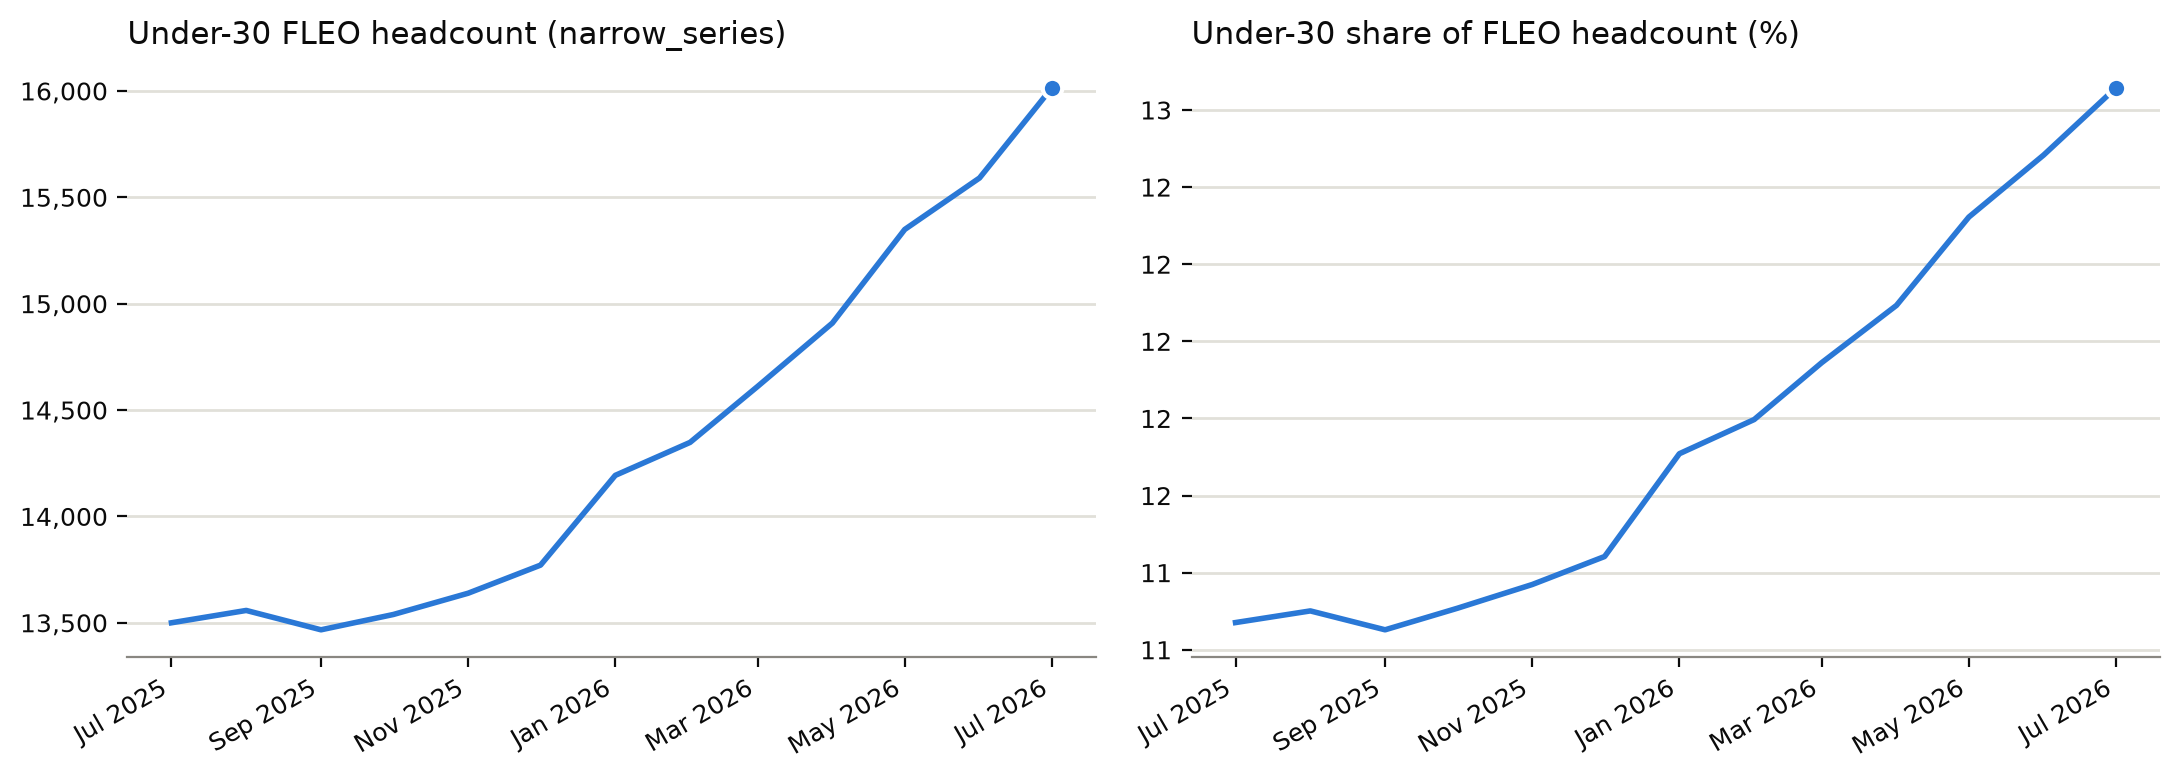

In [8]:
def monthly_one(table, extra_where, group_cols="snapshot_ym", method=VALIDATED_METHOD):
    w = where_clause(method)
    q = f"""
        SELECT {group_cols} AS ym, SUM(count) AS n
        FROM '{table}' WHERE ({w}) AND ({extra_where})
        GROUP BY 1 ORDER BY 1
    """
    return con.execute(q).df().set_index("ym")["n"]

hc_u30 = monthly_one(EMP, U30)
hc_tot = monthly_one(EMP, "1=1")
hc_share = 100 * hc_u30 / hc_tot
hc_u30_dt, hc_share_dt = as_dt_index(hc_u30), as_dt_index(hc_share)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hc_u30_dt.index, hc_u30_dt.values, color=SERIES_COLOR, linewidth=2)
axes[1].plot(hc_share_dt.index, hc_share_dt.values, color=SERIES_COLOR, linewidth=2)
axes[0].plot(hc_u30_dt.index[-1], hc_u30_dt.values[-1], "o", ms=7, color=SERIES_COLOR, markeredgecolor="white", markeredgewidth=1.5, zorder=5)
axes[1].plot(hc_share_dt.index[-1], hc_share_dt.values[-1], "o", ms=7, color=SERIES_COLOR, markeredgecolor="white", markeredgewidth=1.5, zorder=5)
axes[0].set_title("Under-30 FLEO headcount (narrow_series)", fontsize=11, color=INK, loc="left")
axes[1].set_title("Under-30 share of FLEO headcount (%)", fontsize=11, color=INK, loc="left")
for ax in axes:
    style_ax(ax)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(30)
        lbl.set_ha("right")
plt.tight_layout()
plt.show()

## 3. Hiring: under-30 new hires

New-hire accessions (`accession_category LIKE 'NEW HIRE%'`, transfers excluded) for
under-30 age brackets; the newest month (dashed) is provisional per the data notes
above. Also: where these hires are landing (top agencies), and whether agencies are
hiring under-30 officers at a higher rate than the under-30 share of the existing
workforce.


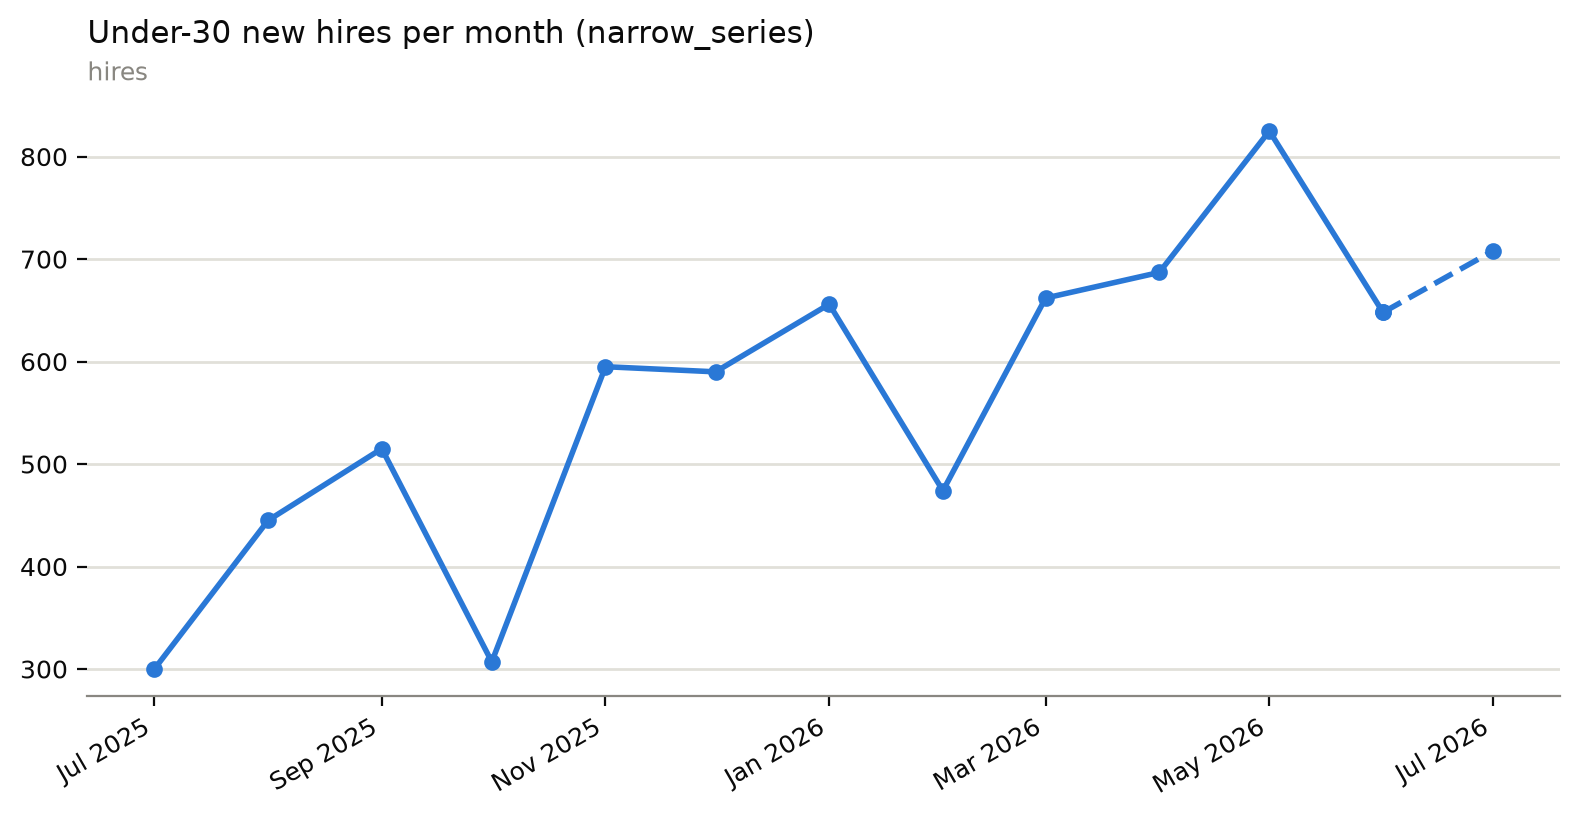

Total under-30 new hires, 2025-07 to 2026-07: 7,412


,agency,under30_hires
0,DEPARTMENT OF HOMELAND SECURITY,5198.0
1,DEPARTMENT OF JUSTICE,1362.0
2,DEPARTMENT OF INTERIOR,278.0
3,DEPARTMENT OF THE AIR FORCE,242.0
4,DEPARTMENT OF THE NAVY,130.0
5,DEPARTMENT OF DEFENSE,68.0
6,DEPARTMENT OF VETERANS AFFAIRS,42.0
7,DEPARTMENT OF TREASURY,40.0
8,DEPARTMENT OF THE ARMY,35.0
9,DEPARTMENT OF HEALTH AND HUMAN SERVICES,5.0


,hires_total,hires_under30,under30_share_of_hires_pct,under30_share_of_headcount_pct
0,15549,7412,47.7,12.8


Under-30 officers are 3.7x overrepresented in hiring (48% of new hires) relative to their share of the existing workforce (13%). DHS alone accounts for 70% of under-30 hires in this window.


In [9]:
hires_u30 = monthly_one(ACC, f"{U30} AND {NEW_HIRE}", "event_ym").loc[WINDOW_START:WINDOW_END]
solid, dashed = as_dt_index(hires_u30.loc[:"202606"]), as_dt_index(hires_u30.loc["202606":])  # overlap at 202606 so the dashed segment connects

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(solid.index, solid.values, color=SERIES_COLOR, marker="o", markersize=5, linewidth=2)
ax.plot(dashed.index, dashed.values, color=SERIES_COLOR, marker="o", markersize=5, linewidth=2, linestyle="--")
ax.set_title("Under-30 new hires per month (narrow_series)", fontsize=11, color=INK, loc="left", pad=22)
style_ax(ax, "hires")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
for lbl in ax.get_xticklabels():
    lbl.set_rotation(30)
    lbl.set_ha("right")
plt.tight_layout()
plt.show()
print(f"Total under-30 new hires, {WINDOW_START[:4]}-{WINDOW_START[4:]} to {WINDOW_END[:4]}-{WINDOW_END[4:]}: {hires_u30.sum():,.0f}")

w = where_clause(VALIDATED_METHOD)
top_agencies = con.execute(f'''
    SELECT agency, SUM(count) AS under30_hires
    FROM '{ACC}'
    WHERE event_ym BETWEEN '{WINDOW_START}' AND '{WINDOW_END}'
      AND {U30} AND {NEW_HIRE} AND ({w})
    GROUP BY 1 ORDER BY under30_hires DESC LIMIT 10
''').df()
display(top_agencies)

h_tot = scalar(f"SELECT SUM(count) FROM '{ACC}' WHERE event_ym BETWEEN '{WINDOW_START}' AND '{WINDOW_END}' AND {NEW_HIRE} AND ({w})")
h_u30 = scalar(f"SELECT SUM(count) FROM '{ACC}' WHERE event_ym BETWEEN '{WINDOW_START}' AND '{WINDOW_END}' AND {NEW_HIRE} AND {U30} AND ({w})")
dhs_hires_u30 = scalar(f"SELECT SUM(count) FROM '{ACC}' WHERE event_ym BETWEEN '{WINDOW_START}' AND '{WINDOW_END}' AND {NEW_HIRE} AND {U30} AND ({w}) AND agency='DEPARTMENT OF HOMELAND SECURITY'")
dhs_share_of_hires = 100 * dhs_hires_u30 / h_u30  # referenced again in Sec. 5

hire_share, hc_share_now = 100 * h_u30 / h_tot, 100 * hc_u30.iloc[-1] / hc_tot.iloc[-1]
display(pd.DataFrame([{
    "hires_total": int(h_tot), "hires_under30": int(h_u30),
    "under30_share_of_hires_pct": round(hire_share, 1),
    "under30_share_of_headcount_pct": round(hc_share_now, 1),
}]))
print(f"Under-30 officers are {hire_share/hc_share_now:.1f}x overrepresented in hiring ({hire_share:.0f}% "
      f"of new hires) relative to their share of the existing workforce ({hc_share_now:.0f}%). "
      f"DHS alone accounts for {dhs_share_of_hires:.0f}% of under-30 hires in this window.")

## 4. Attrition: under-30 separations

Separations (transfers out excluded, DRP quits reported separately per the data notes
above). Attrition **rate** uses average under-30 headcount over the window as the
denominator, compared to the whole FLEO population's rate.


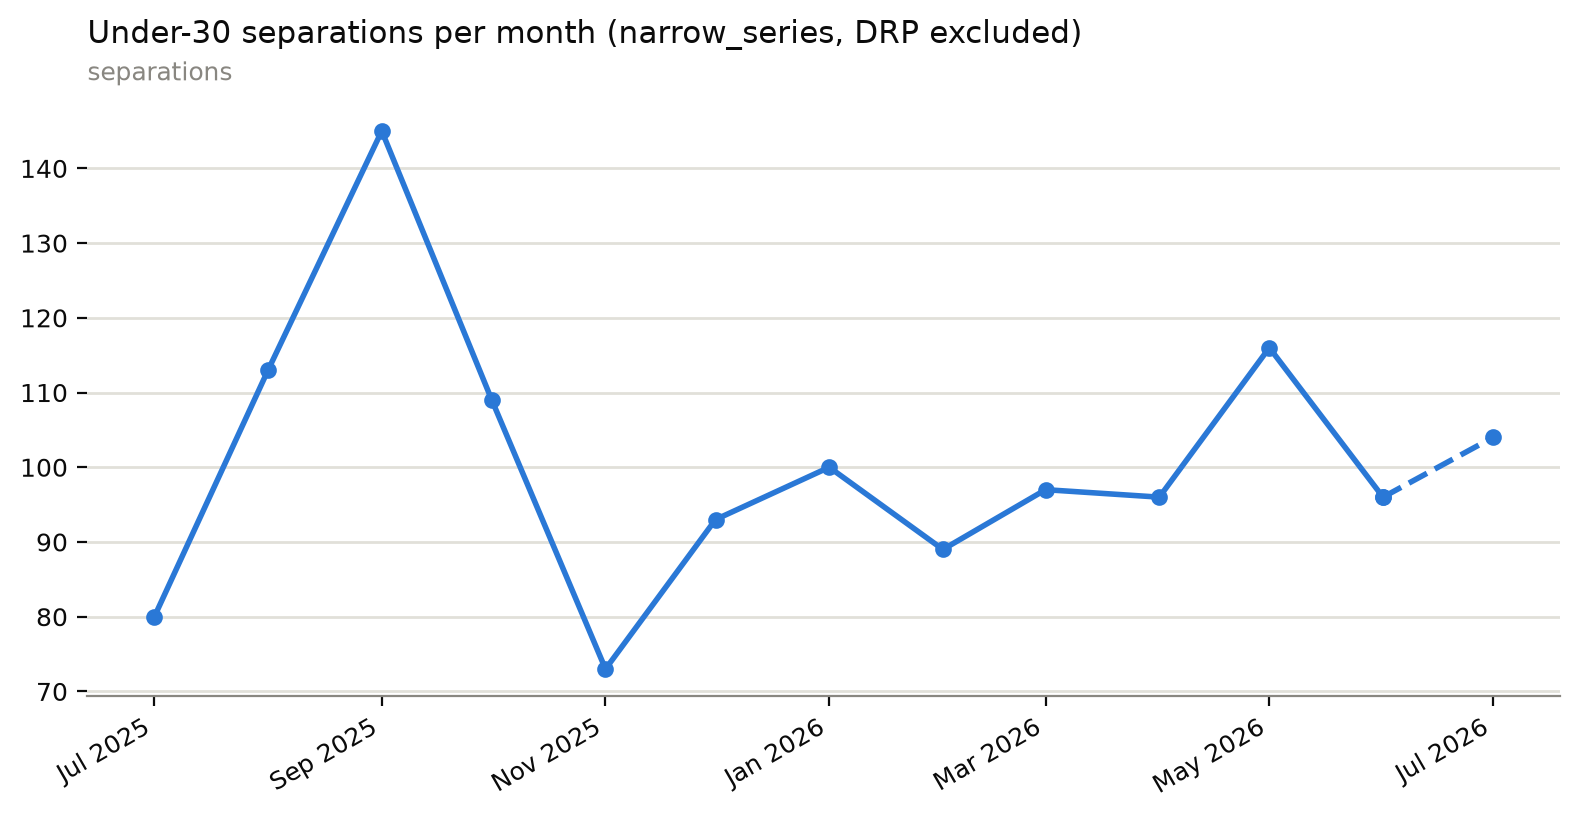

,separation_category,n
0,QUIT,925.0
1,TERMINATION (EXPIRED APPT/OTHER),194.0
2,OTHER SEPARATION,187.0
3,REDUCTION IN FORCE (RIF),3.0
4,RETIREMENT - OTHER,2.0


,under30_separations,under30_avg_headcount,under30_attrition_rate_13mo_pct,allage_attrition_rate_13mo_pct
0,1311,14345,9.1,7.3


Under-30 attrition over this 13-month window (9.1%) runs 1.25x the all-ages rate (7.3%) -- consistent with the 1.19-1.62x range Sec. 5 finds across 2021-2026.


In [10]:
sep_u30 = monthly_one(SEP, f"{U30} AND {NOT_TRANSFER_OUT} AND drp_indicator = 'N'", "event_ym").loc[WINDOW_START:WINDOW_END]
solid, dashed = as_dt_index(sep_u30.loc[:"202606"]), as_dt_index(sep_u30.loc["202606":])  # overlap at 202606 so the dashed segment connects

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(solid.index, solid.values, color=SERIES_COLOR, marker="o", markersize=5, linewidth=2)
ax.plot(dashed.index, dashed.values, color=SERIES_COLOR, marker="o", markersize=5, linewidth=2, linestyle="--")
ax.set_title("Under-30 separations per month (narrow_series, DRP excluded)", fontsize=11, color=INK, loc="left", pad=22)
style_ax(ax, "separations")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
for lbl in ax.get_xticklabels():
    lbl.set_rotation(30)
    lbl.set_ha("right")
plt.tight_layout()
plt.show()

w = where_clause(VALIDATED_METHOD)
sep_cat = con.execute(f'''
    SELECT separation_category, SUM(count) n
    FROM '{SEP}'
    WHERE event_ym BETWEEN '{WINDOW_START}' AND '{WINDOW_END}'
      AND {U30} AND {NOT_TRANSFER_OUT} AND drp_indicator = 'N' AND ({w})
    GROUP BY 1 ORDER BY n DESC
''').df()
display(sep_cat)  # retirement should be ~absent under 30 -- a sanity check, not a finding

sep_tot = scalar(f"SELECT SUM(count) FROM '{SEP}' WHERE event_ym BETWEEN '{WINDOW_START}' AND '{WINDOW_END}' AND {NOT_TRANSFER_OUT} AND drp_indicator='N' AND ({w})")
sep_u = scalar(f"SELECT SUM(count) FROM '{SEP}' WHERE event_ym BETWEEN '{WINDOW_START}' AND '{WINDOW_END}' AND {NOT_TRANSFER_OUT} AND drp_indicator='N' AND {U30} AND ({w})")
u30_rate, allage_rate = 100 * sep_u / hc_u30.mean(), 100 * sep_tot / hc_tot.mean()
display(pd.DataFrame([{
    "under30_separations": int(sep_u),
    "under30_avg_headcount": round(hc_u30.mean()),
    "under30_attrition_rate_13mo_pct": round(u30_rate, 1),
    "allage_attrition_rate_13mo_pct": round(allage_rate, 1),
}]))
print(f"Under-30 attrition over this 13-month window ({u30_rate:.1f}%) runs {u30_rate/allage_rate:.2f}x "
      f"the all-ages rate ({allage_rate:.1f}%) -- consistent with the {attr_ratio_ttm.min():.2f}-{attr_ratio_ttm.max():.2f}x "
      f"range Sec. 5 finds across {HIST_START[:4]}-{HIST_END[:4]}.")

Retirement is essentially absent, as expected under 30 -- this is almost entirely
voluntary quits plus a smaller pool of term-appointment expirations and other
separations; if retirement showed up in real numbers here, it would flag a filtering
bug. *Footnote: under-30 headcount also falls simply because officers turn 30, not
just from attrition -- `Δheadcount ≠ hires - separations` for any age-sliced
population by construction (a month-by-month check, not shown, confirms officers age
out faster than the bracket refills). That matters for reading any longer historical
trend but doesn't change the rate above.*


## 5. Year-over-year: how does this compare to previous years?

Everything above uses the 13-month window. `src/history.py` pulls the same
`narrow_series` definition further back -- 2021 through 2026-07 (67 months) -- to see
whether the current period looks unusual against six years of history. 2026 is a
partial calendar year, but rather than projecting the rest of it from an assumption,
everything below is either (a) the real monthly data, plotted as-is, or (b) a
**trailing-twelve-month (TTM)** figure -- the 12 real months ending at each point,
never a guess about months that haven't happened yet.


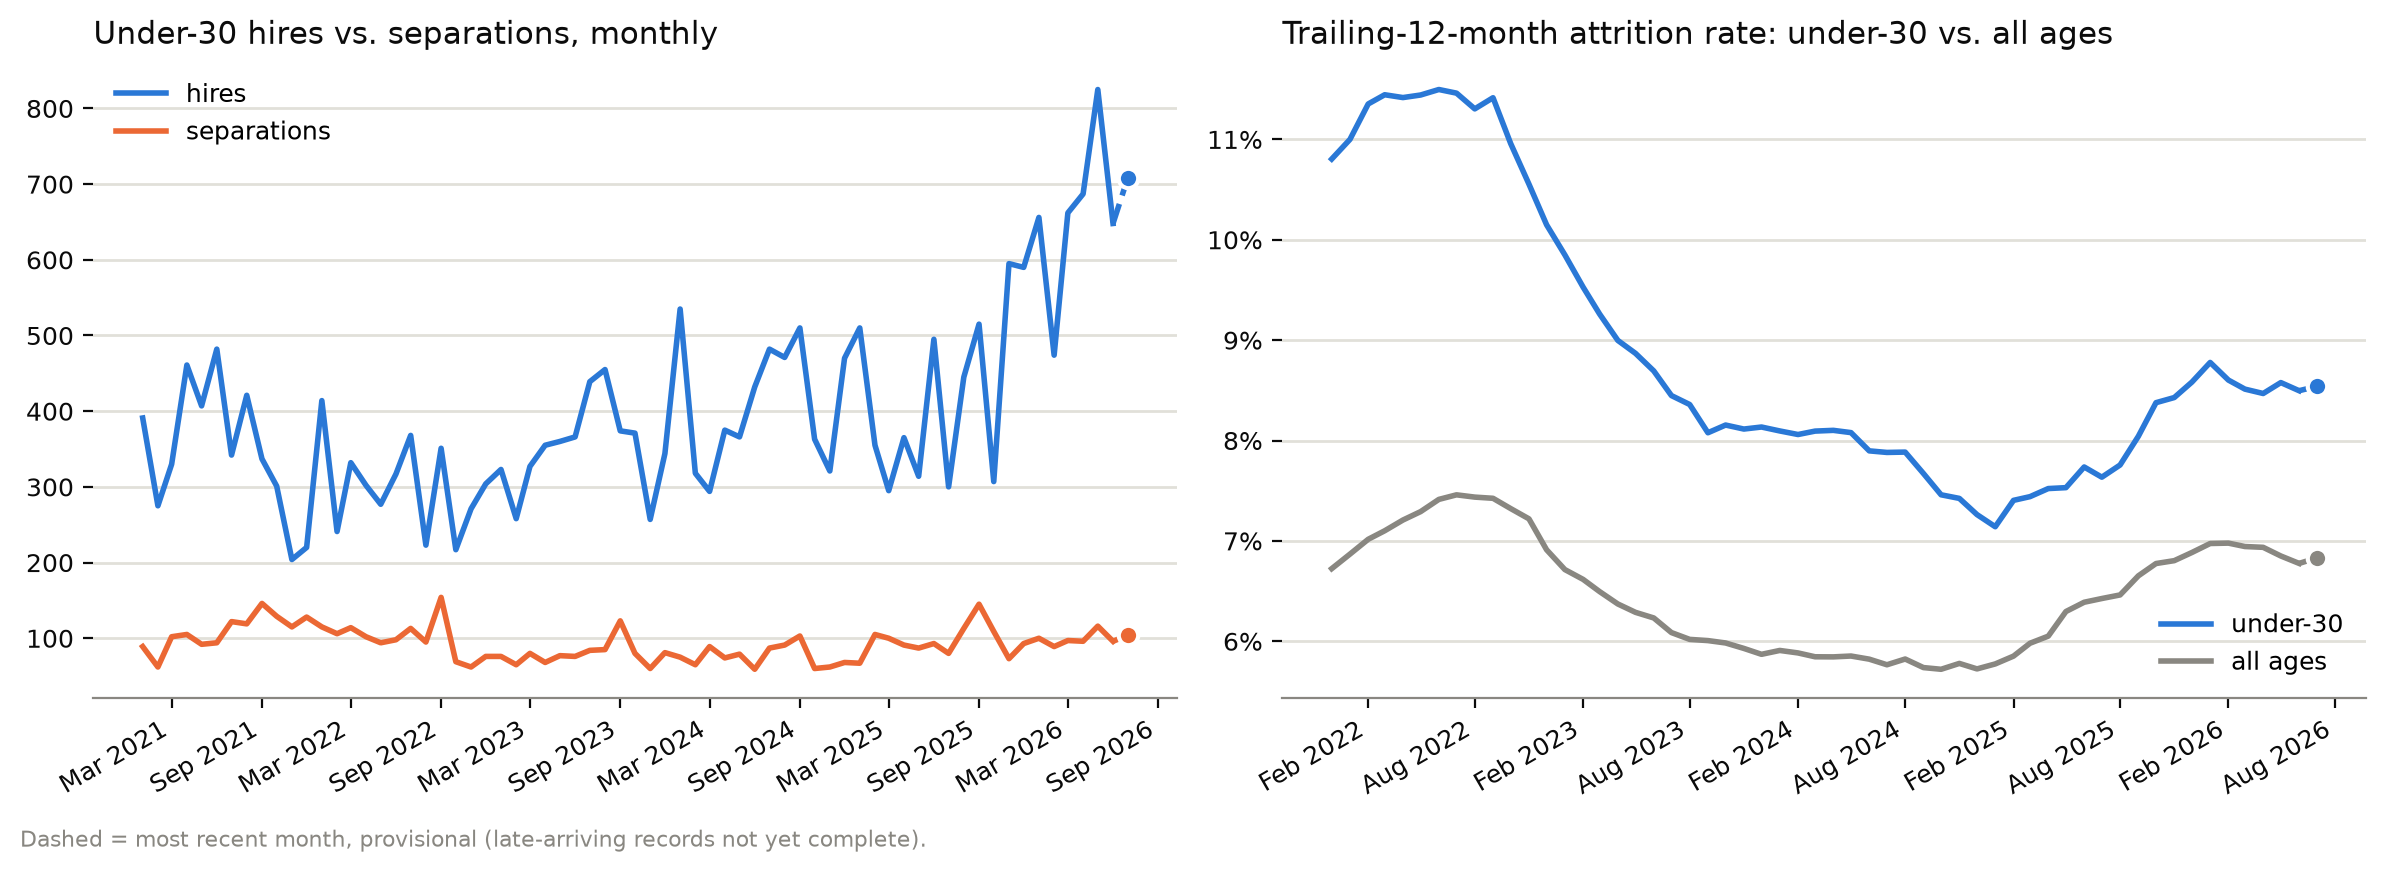

In [11]:
# hires_m/seps_m/hc_m/allage_seps_m/allage_hc_m (monthly) and hires_ttm/seps_ttm/
# hc_ttm_avg/allage_seps_ttm/allage_hc_ttm_avg/attr_rate_ttm/allage_attr_rate_ttm/
# attr_ratio_ttm (trailing-12-month) were already computed above (headline-metrics
# cell, via src/headline.py) -- reused here, not requeried.
def end_dot(ax, x, y, color):
    ax.plot(x[-1], y[-1], "o", ms=7, color=color, markeredgecolor="white", markeredgewidth=1.5, zorder=5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Panel 1: real monthly counts, Jan 2021 - latest month. Last segment dashed (the
# newest month is undercounted -- see data notes above), nothing else is estimated.
hires_dt, seps_dt = as_dt_index(hires_m), as_dt_index(seps_m)
axes[0].plot(hires_dt.index[:-1], hires_dt.values[:-1], color=SERIES_COLOR, linewidth=2, label="hires")
axes[0].plot(hires_dt.index[-2:], hires_dt.values[-2:], color=SERIES_COLOR, linewidth=2, linestyle="--")
axes[0].plot(seps_dt.index[:-1], seps_dt.values[:-1], color=SERIES2_COLOR, linewidth=2, label="separations")
axes[0].plot(seps_dt.index[-2:], seps_dt.values[-2:], color=SERIES2_COLOR, linewidth=2, linestyle="--")
end_dot(axes[0], hires_dt.index, hires_dt.values, SERIES_COLOR)
end_dot(axes[0], seps_dt.index, seps_dt.values, SERIES2_COLOR)
axes[0].set_title("Under-30 hires vs. separations, monthly", fontsize=11, color=INK, loc="left")
axes[0].legend(frameon=False, fontsize=9, loc="upper left")

# Panel 2: trailing-12-month attrition rate, monthly cadence -- the "current pace" at
# each point using only months that have already happened, so no 2026 dashed segment
# is needed except where the newest month feeds the newest TTM window.
attr_dt, allage_dt = as_dt_index(attr_rate_ttm), as_dt_index(allage_attr_rate_ttm)
axes[1].plot(attr_dt.index[:-1], attr_dt.values[:-1], color=SERIES_COLOR, linewidth=2, label="under-30")
axes[1].plot(attr_dt.index[-2:], attr_dt.values[-2:], color=SERIES_COLOR, linewidth=2, linestyle="--")
axes[1].plot(allage_dt.index[:-1], allage_dt.values[:-1], color=MUTED, linewidth=2, label="all ages")
axes[1].plot(allage_dt.index[-2:], allage_dt.values[-2:], color=MUTED, linewidth=2, linestyle="--")
end_dot(axes[1], attr_dt.index, attr_dt.values, SERIES_COLOR)
end_dot(axes[1], allage_dt.index, allage_dt.values, MUTED)
axes[1].set_title("Trailing-12-month attrition rate: under-30 vs. all ages", fontsize=11, color=INK, loc="left")
axes[1].legend(frameon=False, fontsize=9, loc="lower right")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    style_ax(ax)
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(30)
        lbl.set_ha("right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))  # after style_ax, which sets a plain-number formatter
fig.text(0.01, -0.02, "Dashed = most recent month, provisional (late-arriving records not yet complete).",
          fontsize=8, color=MUTED)
plt.tight_layout()
plt.show()

In [12]:
prior_ttm_month = f"{int(PROVISIONAL_MONTH[:4]) - 1}{PROVISIONAL_MONTH[4:]}"  # same month, one year back

hires_ttm_now, hires_ttm_prior = hires_ttm.loc[PROVISIONAL_MONTH], hires_ttm.loc[prior_ttm_month]
hires_ttm_yoy_pct = 100 * (hires_ttm_now - hires_ttm_prior) / hires_ttm_prior
hires_prior_years = hires_yr.loc[:"2025"]
hires_max_yr, hires_max_val = hires_prior_years.idxmax(), hires_prior_years.max()
hires_min_yr, hires_min_val = hires_prior_years.idxmin(), hires_prior_years.min()
hires_ttm_vs_max_pct = 100 * (hires_ttm_now - hires_max_val) / hires_max_val
hires_ttm_vs_min_x = hires_ttm_now / hires_min_val

hc_ttm_start, hc_ttm_now = hc_ttm_avg.iloc[0], hc_ttm_avg.loc[PROVISIONAL_MONTH]
hc_ttm_growth_pct = 100 * (hc_ttm_now - hc_ttm_start) / hc_ttm_start

attr_now, attr_prior = attr_rate_ttm.loc[PROVISIONAL_MONTH], attr_rate_ttm.loc[prior_ttm_month]
attr_ttm_low_month, attr_ttm_low_val = attr_rate_ttm.idxmin(), attr_rate_ttm.min()
attr_ttm_low_month_fmt = f"{attr_ttm_low_month[:4]}-{attr_ttm_low_month[4:]}"
attr_ttm_high_month, attr_ttm_high_val = attr_rate_ttm.idxmax(), attr_rate_ttm.max()
attr_ttm_high_month_fmt = f"{attr_ttm_high_month[:4]}-{attr_ttm_high_month[4:]}"
allage_now = allage_attr_rate_ttm.loc[PROVISIONAL_MONTH]

display(Markdown(f'''
**Headcount** has grown steadily -- the trailing-12-month average under-30 headcount
rose from ~{hc_ttm_start:,.0f} (12 months ending {attr_dt.index[0]:%Y-%m}) to ~{hc_ttm_now:,.0f} (12 months ending
{PROVISIONAL_MONTH_FMT}), a ~{hc_ttm_growth_pct:.0f}% increase.

**Hiring in the last 12 months is the highest on record in this window.** Trailing-12-month
hires ending {PROVISIONAL_MONTH_FMT} ({hires_ttm_now:,.0f}) are up {hires_ttm_yoy_pct:.0f}% from the same trailing window a year
earlier ({hires_ttm_prior:,.0f}), and already {hires_ttm_vs_max_pct:.0f}% above the best *full calendar year* on
record, {hires_max_val:,.0f} in {hires_max_yr} -- {hires_ttm_vs_min_x:.1f}x {hires_min_yr}'s full-year low of {hires_min_val:,.0f}. None of
this needed a seasonal assumption: it's 12 real months, not a projection. Sec. 3 already
showed DHS accounts for ~{dhs_share_of_hires:.0f}% of under-30 hires in the current 13-month window, so
this reads as continuation of the same hiring push, not a new or separate signal.

**Attrition is *not* elevated relative to history, despite the hiring surge.** The
trailing-12-month under-30 rate has moved in a fairly narrow band throughout the window
-- from a low of {attr_ttm_low_val:.1f}% ({attr_ttm_low_month_fmt}) to a high of {attr_ttm_high_val:.1f}% ({attr_ttm_high_month_fmt}) -- and today's
{attr_now:.1f}% ({attr_prior:.1f}% a year earlier) sits well inside that range, not at a new high.
What *is* stable across every month checked: **under-30 attrition consistently runs about
{attr_ratio_ttm.min():.2f}-{attr_ratio_ttm.max():.2f}x the all-ages rate** (today: {attr_now:.1f}% vs. {allage_now:.1f}%) -- a structural
feature of this workforce, not something that emerged in the current hiring surge.
'''))



**Headcount** has grown steadily -- the trailing-12-month average under-30 headcount
rose from ~12,060 (12 months ending 2021-12) to ~14,416 (12 months ending
2026-07), a ~20% increase.

**Hiring in the last 12 months is the highest on record in this window.** Trailing-12-month
hires ending 2026-07 (7,112) are up 49% from the same trailing window a year
earlier (4,769), and already 40% above the best *full calendar year* on
record, 5,086 in 2025 -- 2.0x 2022's full-year low of 3,617. None of
this needed a seasonal assumption: it's 12 real months, not a projection. Sec. 3 already
showed DHS accounts for ~70% of under-30 hires in the current 13-month window, so
this reads as continuation of the same hiring push, not a new or separate signal.

**Attrition is *not* elevated relative to history, despite the hiring surge.** The
trailing-12-month under-30 rate has moved in a fairly narrow band throughout the window
-- from a low of 7.1% (2025-01) to a high of 11.5% (2022-06) -- and today's
8.5% (7.6% a year earlier) sits well inside that range, not at a new high.
What *is* stable across every month checked: **under-30 attrition consistently runs about
1.19-1.62x the all-ages rate** (today: 8.5% vs. 6.8%) -- a structural
feature of this workforce, not something that emerged in the current hiring surge.


In [13]:
display(Markdown(f'''
## 6. Caveats & next steps

- **Sec. 2-4's agency/category detail (top agencies, separation reasons) is still a
  13-month window** ({WINDOW_START[:4]}-{WINDOW_START[4:]} to {WINDOW_END[:4]}-{WINDOW_END[4:]}) -- deliberately short so those checks
  stayed cheap while the FLEO definition was still unsettled. Sec. 5's trend view pulls
  the full {HIST_START[:4]}-{HIST_END[:4]} history at monthly grain now that `narrow_series` is validated;
  extending that same pull's agency/category breakdowns is the natural next step.
- **{PROVISIONAL_MONTH_FMT} (and 2026 overall in Sec. 5) is provisional/partial** (see data notes
  above) -- treat the last point on every chart as a lower bound.
- **Cohort survival is still open.** Sec. 5 compares monthly and trailing-12-month
  flows, not whether a specific hiring class (e.g. everyone hired under 30 in 2021) is
  still employed years later -- that needs individual-level tenure data this extract
  doesn't carry.
- **`narrow_series` still leans on OPM's own occupational-series taxonomy**, and isn't
  a literal match to the statutory LEO definition (Sec. 1b) -- it's the method that
  best matches independent headcount totals, not a claim that every person it counts
  is a "6(c)" law enforcement officer by statute.
- **`pay_plan` and `broad_series` are documented in Sec. 1/1b/`src/fleo_defs.py` but
  not used past that point** -- they undercounted and overcounted the BJS benchmark
  by {abs(vs_bjs["pay_plan"]):.0f}% and {abs(vs_bjs["broad_series"]):.0f}% respectively (Sec. 1b).
- **Small counts may be suppressed/rounded** in the source EHRI extract, as is
  standard OPM practice; the multi-thousand aggregates used here should be well above
  any suppression threshold, but any agency- or series-level cut small enough to
  approach it should be treated with caution.

## References

- 5 U.S.C. §8331(20) (CSRS "law enforcement officer" definition); 5 U.S.C. §8401(17)
  (FERS definition, incl. rigorous-duty standard); 5 C.F.R. §831.802 ("primary duties");
  5 C.F.R. §831.920 and §842.802 (regulatory LEO definition/exclusions); 5 C.F.R.
  §3307(e) ("rigorous position").
- Congressional Research Service. *Retirement Benefits for Federal Law Enforcement
  Personnel.* R42631, updated Aug. 8, 2024.
- U.S. Government Accountability Office. *Federal Police Officers: Considerations on
  Retirement and Pay.* GAO-25-107099, April 2025.
- Bureau of Justice Statistics. *Federal Law Enforcement Officers, 2023 -- Statistical
  Tables.* NCJ, published May 2026 (Census of Federal Law Enforcement Officers).
- Office of Personnel Management. *Federal Law Enforcement Pay and Benefits, Report to
  the Congress.* Washington, DC, July 2004. (Origin of the GL pay-scale / Federal Law
  Enforcement Pay Reform Act of 1990 special base rate discussed in Sec. 1.)
'''))



## 6. Caveats & next steps

- **Sec. 2-4's agency/category detail (top agencies, separation reasons) is still a
  13-month window** (2025-07 to 2026-07) -- deliberately short so those checks
  stayed cheap while the FLEO definition was still unsettled. Sec. 5's trend view pulls
  the full 2021-2026 history at monthly grain now that `narrow_series` is validated;
  extending that same pull's agency/category breakdowns is the natural next step.
- **2026-07 (and 2026 overall in Sec. 5) is provisional/partial** (see data notes
  above) -- treat the last point on every chart as a lower bound.
- **Cohort survival is still open.** Sec. 5 compares monthly and trailing-12-month
  flows, not whether a specific hiring class (e.g. everyone hired under 30 in 2021) is
  still employed years later -- that needs individual-level tenure data this extract
  doesn't carry.
- **`narrow_series` still leans on OPM's own occupational-series taxonomy**, and isn't
  a literal match to the statutory LEO definition (Sec. 1b) -- it's the method that
  best matches independent headcount totals, not a claim that every person it counts
  is a "6(c)" law enforcement officer by statute.
- **`pay_plan` and `broad_series` are documented in Sec. 1/1b/`src/fleo_defs.py` but
  not used past that point** -- they undercounted and overcounted the BJS benchmark
  by 73% and 78% respectively (Sec. 1b).
- **Small counts may be suppressed/rounded** in the source EHRI extract, as is
  standard OPM practice; the multi-thousand aggregates used here should be well above
  any suppression threshold, but any agency- or series-level cut small enough to
  approach it should be treated with caution.

## References

- 5 U.S.C. §8331(20) (CSRS "law enforcement officer" definition); 5 U.S.C. §8401(17)
  (FERS definition, incl. rigorous-duty standard); 5 C.F.R. §831.802 ("primary duties");
  5 C.F.R. §831.920 and §842.802 (regulatory LEO definition/exclusions); 5 C.F.R.
  §3307(e) ("rigorous position").
- Congressional Research Service. *Retirement Benefits for Federal Law Enforcement
  Personnel.* R42631, updated Aug. 8, 2024.
- U.S. Government Accountability Office. *Federal Police Officers: Considerations on
  Retirement and Pay.* GAO-25-107099, April 2025.
- Bureau of Justice Statistics. *Federal Law Enforcement Officers, 2023 -- Statistical
  Tables.* NCJ, published May 2026 (Census of Federal Law Enforcement Officers).
- Office of Personnel Management. *Federal Law Enforcement Pay and Benefits, Report to
  the Congress.* Washington, DC, July 2004. (Origin of the GL pay-scale / Federal Law
  Enforcement Pay Reform Act of 1990 special base rate discussed in Sec. 1.)
